# **Pre-trained models**

### **Wikiart Project**

**Group 22:**\
**Afonso Hermenegildo** - 20221958 | **André Ferreira** - 20250398 | **André Nicolau** - 20221918 | **Lara Santos** - 20221823 | **Marco Martins** - 20221951

Github repository: https://github.com/MarcoAFMartins/Wikiart_Project

---

# Table of Contents

1. *Exploratory Data Analysis*
    * 1.1. *Importing Data*
    * 1.2. *Dataset Overview and Class Imbalance*
        * 1.2.1 *Data Exploration*
        * 1.2.2. *File size distribution*
    * 1.3. *Visual characteristics*
        * 1.3.1. *Samples per class*
        * 1.3.2. *Average Image per Artist*
        * 1.3.3. *Mean Pixel Intensity per Class*
    * 1.4. *Grayscale Images*
    * 1.5. *Data Quality Check*
    * 1.6. *Outliers*
2. *Removing Duplicates*


---

## 0. Imports and GPU config

In [ ]:
import sys
sys.path.append('..')
sys.path.append('../scripts')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # hide tensorflow errors

import tensorflow as tf
import keras
from keras import layers

from models_utils import plot_model_history

Check if our GPU is detected

In [2]:
gpus = tf.config.list_physical_devices('GPU')
gpus

W0000 00:00:1776962806.125478    2682 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Configure memory limit to take advantage of all of our VRAM

In [3]:
for gpu in gpus:
    tf.config.set_logical_device_configuration(
        gpu,
        [tf.config.LogicalDeviceConfiguration(memory_limit=round(7.5*1024))]
    )

## 1. Data import

In [2]:
image_size = (512, 512) # use original image size
input_shape = image_size + (3,)
batch_size = 4 # use a smaller value since we are using a bigger resolution
n_classes = 23

train_ds = keras.utils.image_dataset_from_directory(
    "../clean_split_data/train",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical"
)

val_ds = keras.utils.image_dataset_from_directory(
    "../clean_split_data/validation",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical"
)

NameError: name 'keras' is not defined

## 2. VGG16

<img src="../images/vgg16.png" width="50%"/>

VGG16 was developed in Oxford University and it is a simple but big model in terms of parameters. It just stacks 3x3 convolutional layers followed by max pooling layers, in five blocks and ends with three fully connected layers. It has a big parameter count because of the big fully connected layers at the end and the flatten layer, so it is not very parameter efficient.

In [14]:
vgg16_base_model = keras.applications.VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=input_shape,
    classes=23
)

vgg16_base_model.trainable = False

In [ ]:
inputs = keras.Input(shape=input_shape)

# try resizing the image to the default image size of VGG16
# x = layers.Resizing(224, 224)(inputs)

# try augmentation
x = layers.Pipeline(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomBrightness(factor=0.08),
        layers.RandomContrast(factor=0.08),
        layers.RandomRotation(factor=0.02, fill_mode="reflect"),
        layers.RandomZoom((-0.05, 0.05), fill_mode="reflect"),
        layers.RandomTranslation(
            height_factor=0.05, width_factor=0.05, fill_mode="reflect"
        ),
        layers.GaussianNoise(stddev=0.02),
    ],
    name="augmentation_moderate_noise",
)(inputs)

# apply VGG16 preprocessing
# The images are converted from RGB to BGR, then each color channel 
# is zero-centered with respect to the ImageNet dataset, without scaling.
x = keras.applications.vgg16.preprocess_input(x)

x = vgg16_base_model(x, training=False)

# x = layers.Flatten()(x)
# use Flatten like VGG16 originally
# or GlobalAveragePooling to reduce the number of trainable params
x = layers.GlobalAveragePooling2D()(x)

# try dropout
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(n_classes, activation="softmax")(x)

vgg16_pre_trained_model = keras.Model(inputs=inputs, outputs=outputs, name="vgg16_pre_trained")

In [16]:
vgg16_pre_trained_model.summary()

Model: "vgg16_pre_trained"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation_moder… │ (None, 512, 512,  │          0 │ input_layer_1[0]… │
│ (Pipeline)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 512, 512)  │          0 │ augmentation_mod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 512, 512)  │          0 │ augmentation_mod… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 512, 512)  │          0 │ augmentation_mod… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 512, 512,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512, 512,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 16, 16,    │ 14,714,688 │ add[0][0]         │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 23)        │     11,799 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,726,487 (56.18 MB)

 Trainable params: 11,799 (46.09 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [17]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [18]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10


2333/2333 ━━━━━━━━━━━━━━━━━━━━ 644s 273ms/step - categorical_accuracy: 0.4786 - f1_score: 0.4435 - loss: 2.0934 - val_categorical_accuracy: 0.6138 - val_f1_score: 0.5729 - val_loss: 1.5092
Epoch 2/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 662s 284ms/step - categorical_accuracy: 0.6301 - f1_score: 0.6024 - loss: 1.3643 - val_categorical_accuracy: 0.6368 - val_f1_score: 0.5973 - val_loss: 1.5122
Epoch 3/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 657s 281ms/step - categorical_accuracy: 0.6664 - f1_score: 0.6427 - loss: 1.2187 - val_categorical_accuracy: 0.6733 - val_f1_score: 0.6489 - val_loss: 1.2996
Epoch 4/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 648s 278ms/step - categorical_accuracy: 0.6760 - f1_score: 0.6537 - loss: 1.1760 - val_categorical_accuracy: 0.6808 - val_f1_score: 0.6564 - val_loss: 1.3154
Epoch 5/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 652s 279ms/step - categorical_accuracy: 0.6825 - f1_score: 0.6610 - loss: 1.1626 - val_categorical_accuracy: 0.6748 - val_f1_score: 0.6516 - val_loss: 1.3472


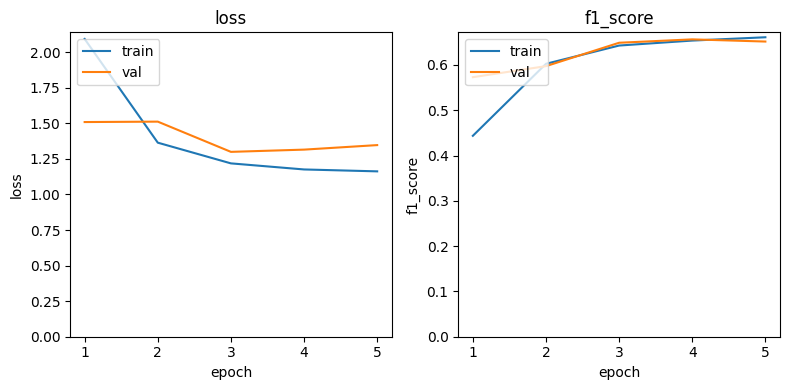

In [19]:
plot_model_history(vgg16_pre_trained_model_history, ["loss", "f1_score"])

In [20]:
vgg16_pre_trained_model.save("../outputs/models/vgg16_pre_trained.keras")

## 3. ResNet

<img src="../images/resnet50.png?" width="90%"/>

ResNet was developed at Microsoft Research and it introduced the idea of the residual connection. This allowed to train much deeper networks with the biggest variant having 152 layers. It also changed the Flatten layer used in VGG to a GlobalAveragePooling which made it more parameter efficient.

In V2, the authors applied BatchNormalization and activation before each convolution, instead of after in V1.

From the ResNet family of models, the one we chose was ResNet152V2, as it was the one with the best performance and it still could be trained in our GPU.

In [16]:
resnet152v2_base_model = keras.applications.ResNet152V2(
    include_top=False,
    weights="imagenet",
    input_shape=input_shape,
    classes=23
)

# freeze the layers
resnet152v2_base_model.trainable = False

In [17]:
inputs = keras.Input(shape=input_shape)

x = layers.Pipeline(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomBrightness(factor=0.08),
        layers.RandomContrast(factor=0.08),
        layers.RandomRotation(factor=0.02, fill_mode="reflect"),
        layers.RandomZoom((-0.05, 0.05), fill_mode="reflect"),
        layers.RandomTranslation(
            height_factor=0.05, width_factor=0.05, fill_mode="reflect"
        ),
        layers.GaussianNoise(stddev=0.02),
    ],
    name="augmentation_moderate_noise",
)(inputs)

# apply ResNet preprocessing
# The inputs pixel values are scaled between -1 and 1, sample-wise.
x = keras.applications.resnet_v2.preprocess_input(x)

x = resnet152v2_base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(n_classes, activation="softmax")(x)

resnet152v2_pre_trained_model = keras.Model(inputs=inputs, outputs=outputs, name="resnet152v2_pre_trained")

In [18]:
resnet152v2_pre_trained_model.summary()

Model: "resnet152v2_pre_trained"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate_noise     │ (None, 512, 512, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet152v2 (Functional)        │ (None, 16, 16, 2048)   │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 23)             │        47,127 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,378,775 (222.70 MB)

 Trainable params: 47,127 (184.09 KB)

 Non-trainable params: 58,331,648 (222.52 MB)

In [19]:
resnet152v2_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [20]:
resnet152v2_pre_trained_model_history = resnet152v2_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 740s 311ms/step - categorical_accuracy: 0.5931 - f1_score: 0.5625 - loss: 1.4042 - val_categorical_accuracy: 0.7034 - val_f1_score: 0.6621 - val_loss: 1.0167
Epoch 2/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 711s 305ms/step - categorical_accuracy: 0.7251 - f1_score: 0.7042 - loss: 0.9130 - val_categorical_accuracy: 0.7274 - val_f1_score: 0.6949 - val_loss: 0.9198
Epoch 3/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 712s 305ms/step - categorical_accuracy: 0.7630 - f1_score: 0.7463 - loss: 0.7869 - val_categorical_accuracy: 0.7354 - val_f1_score: 0.7030 - val_loss: 0.8963
Epoch 4/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 713s 306ms/step - categorical_accuracy: 0.7791 - f1_score: 0.7656 - loss: 0.7086 - val_categorical_accuracy: 0.7569 - val_f1_score: 0.7346 - val_loss: 0.8321
Epoch 5/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 708s 303ms/step - categorical_accuracy: 0.7937 - f1_score: 0.7808 - loss: 0.6614 - val_categorical_accuracy: 0.7569 - val_f1_score: 0.7352 - val_loss: 0.8144


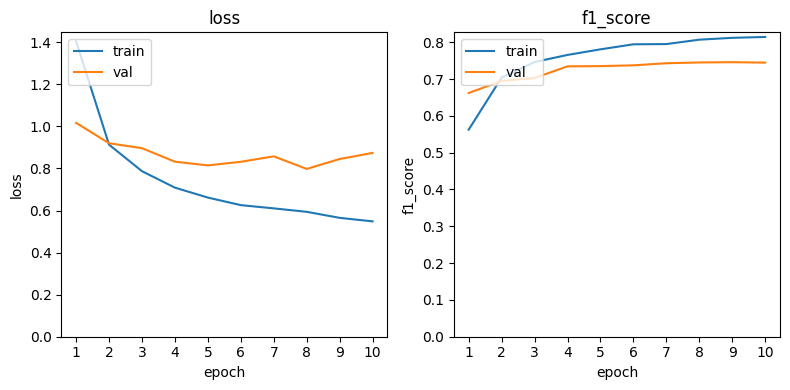

In [21]:
plot_model_history(resnet152v2_pre_trained_model_history, ["loss", "f1_score"])

## 4. EfficientNet

<img src="../images/efficient_net_b0.png" width="70%"/>

EfficientNet was developed at Google Brain and it introduced compound scaling: scaling depth (number of layers), width (channels) and resolution at the same time, which gives us more accurate and parameter-efficient models at the same computational cost. The building block for EfficientNetV1 is MBConv (Mobile Inverted Bottleneck Convolution) which was borrowed from MobileNetV2. In V2 the authors replaced the early MBConv blocks with Fused-MBConv which speeds up training.

In [5]:
efficient_net_v2_b3_base_model = keras.applications.EfficientNetV2B3(
    include_top=False,
    weights="imagenet",
    input_shape=input_shape,
    classes=23,
    include_preprocessing=True # efficient net includes preprocessing inside the model
)

# freeze the layers
efficient_net_v2_b3_base_model.trainable = False

In [6]:
inputs = keras.Input(shape=input_shape)

x = efficient_net_v2_b3_base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(n_classes, activation="softmax")(x)

efficient_net_v2_b3_pre_trained_model = keras.Model(inputs=inputs, outputs=outputs, name="efficient_net_v2_b3_pre_trained")

In [7]:
efficient_net_v2_b3_pre_trained_model.summary()

Model: "efficient_net_v2_b3_pre_trained"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b3 (Functional)  │ (None, 16, 16, 1536)   │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        35,351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,965,973 (49.46 MB)

 Trainable params: 35,351 (138.09 KB)

 Non-trainable params: 12,930,622 (49.33 MB)

In [8]:
efficient_net_v2_b3_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [9]:
efficient_net_v2_b3_pre_trained_model_history = efficient_net_v2_b3_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True, patience=2)
)

Epoch 1/10


I0000 00:00:1776969417.963989  512281 service.cc:152] XLA service 0x7c8cc00030a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776969417.964050  512281 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
I0000 00:00:1776969420.903090  512281 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776969445.009431  512281 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2333/2333 ━━━━━━━━━━━━━━━━━━━━ 235s 82ms/step - categorical_accuracy: 0.6215 - f1_score: 0.5900 - loss: 1.3261 - val_categorical_accuracy: 0.7284 - val_f1_score: 0.7054 - val_loss: 0.9364
Epoch 2/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 139s 60ms/step - categorical_accuracy: 0.7450 - f1_score: 0.7252 - loss: 0.8768 - val_categorical_accuracy: 0.7679 - val_f1_score: 0.7507 - val_loss: 0.8014
Epoch 3/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 133s 57ms/step - categorical_accuracy: 0.7798 - f1_score: 0.7646 - loss: 0.7352 - val_categorical_accuracy: 0.7844 - val_f1_score: 0.7699 - val_loss: 0.7459
Epoch 4/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 133s 57ms/step - categorical_accuracy: 0.7931 - f1_score: 0.7790 - loss: 0.6754 - val_categorical_accuracy: 0.7854 - val_f1_score: 0.7754 - val_loss: 0.7522
Epoch 5/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 134s 57ms/step - categorical_accuracy: 0.8165 - f1_score: 0.8055 - loss: 0.6099 - val_categorical_accuracy: 0.7929 - val_f1_score: 0.7786 - val_loss: 0.7349
Epoch 6/10
2333/

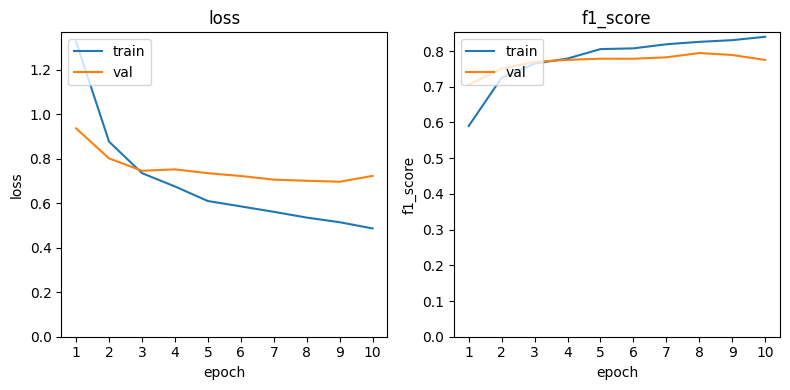

In [10]:
plot_model_history(efficient_net_v2_b3_pre_trained_model_history, ["loss", "f1_score"])

In [11]:
efficient_net_v2_b3_pre_trained_model.save("../outputs/models/efficient_net_v2_b3_pre_trained.keras")

## 5. ConvNeXt

<img src="../images/convnext.png" width="50%"/>

ConvNeXt was developed at Meta and UC Berkeley and it was created to compete with Vision Transformers. The authors started with a standard ResNet architecture and incorporated design choices that made transformers effective.

It changes the standard 3x3 convolutions to 7x7 depthwise convolutions, replaces ReLU with GELU, reduces the number of activation and normalization layers and substitutes Batch Normalization with Layer Normalization.

From the family of models, first we tried ConvNeXt XLarge, but we couldn't train it because of insufficient memory, so we used ConvNeXt Large.

In [5]:
convnext_large_base_model = keras.applications.ConvNeXtLarge(
    include_top=False,
    weights="imagenet",
    input_shape=input_shape,
    classes=23,
    include_preprocessing=True
)

# freeze the layers
convnext_large_base_model.trainable = False

In [6]:
inputs = keras.Input(shape=input_shape)

x = convnext_large_base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(n_classes, activation="softmax")(x)

convnext_large_pre_trained_model = keras.Model(inputs=inputs, outputs=outputs, name="convnext_large_pre_trained")

In [7]:
convnext_large_pre_trained_model.summary()

Model: "convnext_large_pre_trained"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_large (Functional)     │ (None, 16, 16, 1536)   │   196,230,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        35,351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,265,687 (748.69 MB)

 Trainable params: 35,351 (138.09 KB)

 Non-trainable params: 196,230,336 (748.56 MB)

In [8]:
convnext_large_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [9]:
convnext_large_pre_trained_model_history = convnext_large_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True, patience=2)
)

Epoch 1/10


I0000 00:00:1776896466.471903    3426 service.cc:152] XLA service 0x76f0e4002a30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776896466.471951    3426 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
I0000 00:00:1776896468.987988    3426 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776896489.854785    3426 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2333/2333 ━━━━━━━━━━━━━━━━━━━━ 1248s 520ms/step - categorical_accuracy: 0.6854 - f1_score: 0.6646 - loss: 1.0763 - val_categorical_accuracy: 0.8099 - val_f1_score: 0.7970 - val_loss: 0.6721
Epoch 2/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 1133s 486ms/step - categorical_accuracy: 0.8299 - f1_score: 0.8192 - loss: 0.5675 - val_categorical_accuracy: 0.8329 - val_f1_score: 0.8223 - val_loss: 0.5510
Epoch 3/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 1134s 486ms/step - categorical_accuracy: 0.8678 - f1_score: 0.8600 - loss: 0.4263 - val_categorical_accuracy: 0.8469 - val_f1_score: 0.8358 - val_loss: 0.5052
Epoch 4/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 1131s 485ms/step - categorical_accuracy: 0.8941 - f1_score: 0.8874 - loss: 0.3441 - val_categorical_accuracy: 0.8514 - val_f1_score: 0.8430 - val_loss: 0.4877
Epoch 5/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 1135s 487ms/step - categorical_accuracy: 0.9117 - f1_score: 0.9079 - loss: 0.3000 - val_categorical_accuracy: 0.8504 - val_f1_score: 0.8384 - val_loss: 0.4950
Epoch 

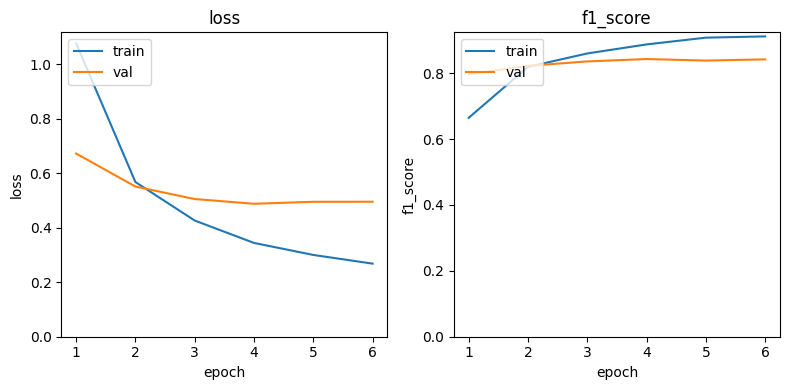

In [10]:
plot_model_history(convnext_large_pre_trained_model_history, ["loss", "f1_score"])

In [11]:
convnext_large_pre_trained_model.save("../outputs/models/convnext_large_pre_trained.keras")

## 6. Fine-tuning

### 6.1. Fully fine-tuning a smaller model

For fine-tuning we used ConvNeXt Tiny, as it was the only model from the ConvNeXt family that we could fully fine-tune

In [12]:
convnext_tiny_base_model = keras.applications.ConvNeXtTiny(
    include_top=False,
    weights="imagenet",
    input_shape=input_shape,
    classes=23,
    include_preprocessing=True
)

# freeze the layers
convnext_tiny_base_model.trainable = False

In [13]:
inputs = keras.Input(shape=input_shape)

x = convnext_tiny_base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(n_classes, activation="softmax")(x)

convnext_tiny_pre_trained_model = keras.Model(inputs=inputs, outputs=outputs, name="convnext_tiny_pre_trained")

In [14]:
convnext_tiny_pre_trained_model.summary()

Model: "convnext_tiny_pre_trained"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 16, 16, 768)    │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │        17,687 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,837,815 (106.19 MB)

 Trainable params: 17,687 (69.09 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

In [15]:
convnext_tiny_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [16]:
convnext_tiny_pre_trained_model_history = convnext_tiny_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True) # removed patience=2 since we will finetune after
)

Epoch 1/10


2333/2333 ━━━━━━━━━━━━━━━━━━━━ 312s 120ms/step - categorical_accuracy: 0.5573 - f1_score: 0.5271 - loss: 1.6124 - val_categorical_accuracy: 0.7109 - val_f1_score: 0.6756 - val_loss: 1.1046
Epoch 2/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 250s 107ms/step - categorical_accuracy: 0.7278 - f1_score: 0.7121 - loss: 0.9872 - val_categorical_accuracy: 0.7489 - val_f1_score: 0.7209 - val_loss: 0.9083
Epoch 3/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 251s 108ms/step - categorical_accuracy: 0.7701 - f1_score: 0.7571 - loss: 0.8228 - val_categorical_accuracy: 0.7689 - val_f1_score: 0.7425 - val_loss: 0.8212
Epoch 4/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 251s 108ms/step - categorical_accuracy: 0.7958 - f1_score: 0.7842 - loss: 0.7237 - val_categorical_accuracy: 0.7754 - val_f1_score: 0.7495 - val_loss: 0.7677
Epoch 5/10
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 252s 108ms/step - categorical_accuracy: 0.8137 - f1_score: 0.8029 - loss: 0.6710 - val_categorical_accuracy: 0.7894 - val_f1_score: 0.7662 - val_loss: 0.7327
Epoch 6/10


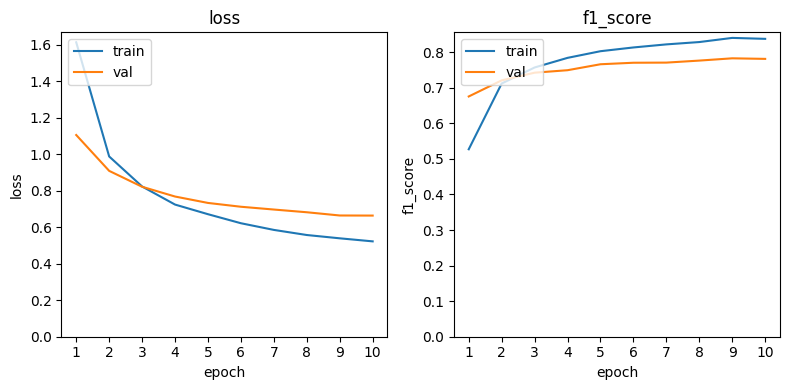

In [17]:
plot_model_history(convnext_tiny_pre_trained_model_history, ["loss", "f1_score"])

In [18]:
convnext_tiny_pre_trained_model.save("../outputs/models/convnext_tiny_pre_trained.keras")

Now apply the fine-tuning, using a lower learning rate and SGD to save memory so that we can fit larger models

In [19]:
convnext_tiny_pre_trained_model.layers[1].name

'convnext_tiny'

In [20]:
convnext_tiny_pre_trained_model.layers[1].trainable = True

In [21]:
convnext_tiny_pre_trained_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=1e-5), # use much lower learning rate for fine-tuning and SGD to save memory
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [22]:
convnext_tiny_pre_trained_model_history2 = convnext_tiny_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/5
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 978s 404ms/step - categorical_accuracy: 0.8645 - f1_score: 0.8592 - loss: 0.4693 - val_categorical_accuracy: 0.8109 - val_f1_score: 0.7927 - val_loss: 0.6506
Epoch 2/5
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 912s 391ms/step - categorical_accuracy: 0.8644 - f1_score: 0.8594 - loss: 0.4668 - val_categorical_accuracy: 0.8084 - val_f1_score: 0.7905 - val_loss: 0.6464


In [23]:
convnext_tiny_pre_trained_model.save("../outputs/models/convnext_tiny_finetuned.keras")

### 6.2. Fine-tuning just the final layers of the large model

Load the ConvNeXt Large model we already trained

In [5]:
convnext_large_pre_trained_model = keras.saving.load_model("../outputs/models/convnext_large_pre_trained.keras")

Unfreeze only stage 3 block 2, which is 18 million parameters, the biggest we can fit in our VRAM

In [6]:
for layer in convnext_large_pre_trained_model.layers[1].layers:
    if "stage_3_block_2" in layer.name:
        layer.trainable = True

In [7]:
convnext_large_pre_trained_model.summary()

Model: "convnext_large_pre_trained"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_large (Functional)     │ (None, 16, 16, 1536)   │   196,230,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        35,351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,336,391 (748.96 MB)

 Trainable params: 18,998,807 (72.47 MB)

 Non-trainable params: 177,266,880 (676.22 MB)

 Optimizer params: 70,704 (276.19 KB)

In [9]:
convnext_large_pre_trained_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=1e-5), # use much lower learning rate for fine-tuning and SGD to save memory
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [10]:
convnext_large_pre_trained_model_history2 = convnext_large_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/5


I0000 00:00:1776949268.929926  322266 service.cc:152] XLA service 0x77a57c053330 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776949268.930039  322266 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
I0000 00:00:1776949271.947701  322266 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776949293.702691  322266 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2333/2333 ━━━━━━━━━━━━━━━━━━━━ 1409s 589ms/step - categorical_accuracy: 0.9253 - f1_score: 0.9220 - loss: 0.2529 - val_categorical_accuracy: 0.8544 - val_f1_score: 0.8454 - val_loss: 0.4830
Epoch 2/5
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 1752s 751ms/step - categorical_accuracy: 0.9261 - f1_score: 0.9234 - loss: 0.2460 - val_categorical_accuracy: 0.8564 - val_f1_score: 0.8475 - val_loss: 0.4792
Epoch 3/5
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 2214s 949ms/step - categorical_accuracy: 0.9332 - f1_score: 0.9309 - loss: 0.2416 - val_categorical_accuracy: 0.8579 - val_f1_score: 0.8488 - val_loss: 0.4760
Epoch 4/5
2333/2333 ━━━━━━━━━━━━━━━━━━━━ 1316s 564ms/step - categorical_accuracy: 0.9293 - f1_score: 0.9272 - loss: 0.2397 - val_categorical_accuracy: 0.8574 - val_f1_score: 0.8480 - val_loss: 0.4731


In [11]:
convnext_large_pre_trained_model.save("../outputs/models/convnext_large_finetuned.keras")

## 7. Final Models

<table><thead>
  <tr>
    <th>Model</th>
    <th>F1 Score</th>
    <th>Accuracy</th>
  </tr></thead>
<tbody>
  <tr>
    <td>VGG16</td>
    <td>0.6564</td>
    <td>0.6808</td>
  </tr>
  <tr>
    <td>ResNet152V2</td>
    <td>0.7459</td>
    <td>0.7654</td>
  </tr>
  <tr>
    <td>EfficientNetV2B3</td>
    <td>0.7945</td>
    <td>0.8084</td>
  </tr>
  <tr>
    <td>ConvNeXt Large</td>
    <td>0.8430</td>
    <td>0.8514</td>
  </tr>
</tbody>
</table>

### Fine-tuned models

<table><thead>
  <tr>
    <th>Model</th>
    <th>F1 Score</th>
    <th>Accuracy</th>
  </tr></thead>
<tbody>
  <tr>
    <td>ConvNeXt Tiny Fine-tuned</td>
    <td>0.7927</td>
    <td>0.8109</td>
  </tr>
  <tr>
    <td>ConvNeXt Large Fine-tuned (last layer)</td>
    <td>0.8488</td>
    <td>0.8579</td>
  </tr>
</tbody>
</table>